In [2]:
import pandas as pd 
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.DataFrame(pd.read_csv(r'C:\Users\MSI\Desktop\Heart Disease\Data\data.csv'))

In [4]:
# Convert column to string and strip extra spaces so that we encode them
df["Heart Disease"] = df["Heart Disease"].astype(str).str.strip()
# Remove leading/trailing spaces and standardize
df["Heart Disease"] = df["Heart Disease"].map({"Absence": 0, "Presence": 1})
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [ ]:
#we are going to drop around 36K samples with label 0 in order to balance the dataset .
rows_with_0 = df[df["Heart Disease"] == 0]
rows_to_drop = rows_with_0.sample(36000, random_state=42)  # random 36000
df = df.drop(rows_to_drop.index)
df["Heart Disease"].value_counts()

Heart Disease
0    284546
1    282454
Name: count, dtype: int64

In [12]:
# Define features and target variable ,we'll use only numerical features for simplicity and the most correlated ones with our target variable
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
X = df[numerical_features]
y = df["Heart Disease"]

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42, stratify=y)

In [14]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 453600
Testing samples: 113400


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


Train Accuracy: 0.8469
Test Accuracy:  0.8486


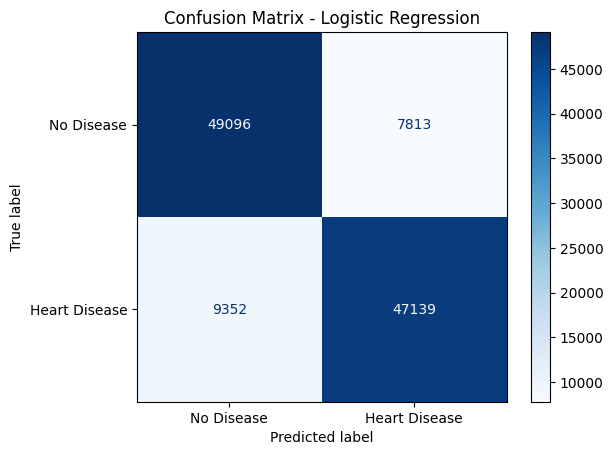

Classification Report - Logistic Regression:
               precision    recall  f1-score   support

   No Disease       0.84      0.86      0.85     56909
Heart Disease       0.86      0.83      0.85     56491

     accuracy                           0.85    113400
    macro avg       0.85      0.85      0.85    113400
 weighted avg       0.85      0.85      0.85    113400



In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Logistic Regression with balanced class weights
model = LogisticRegression(random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = model.predict(X_train_scaled)   # 👈 NEW
y_pred_test = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)   # 👈 NEW
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Heart Disease"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Classification Report
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_test, target_names=["No Disease", "Heart Disease"]))

In [ ]:
#Adding More features to our model and re-evaluating it
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]
# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

Accuracy: 0.8781481481481481
               precision    recall  f1-score   support

   No Disease       0.88      0.88      0.88     56909
Heart Disease       0.88      0.88      0.88     56491

     accuracy                           0.88    113400
    macro avg       0.88      0.88      0.88    113400
 weighted avg       0.88      0.88      0.88    113400



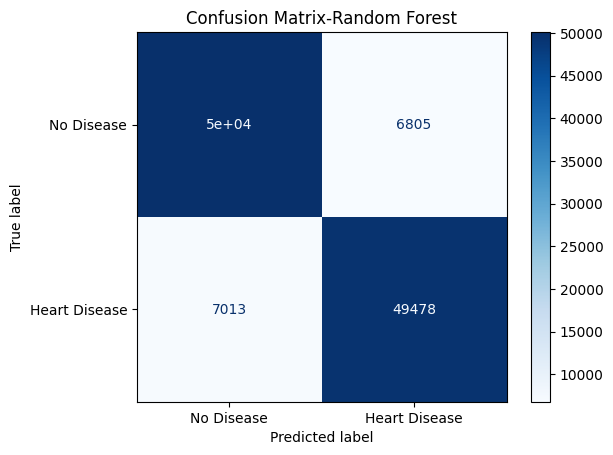

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix-Random Forest")
plt.show()

c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [14:41:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.8869

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.89      0.89     57709
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    114200
    macro avg       0.89      0.89      0.89    114200
 weighted avg       0.89      0.89      0.89    114200



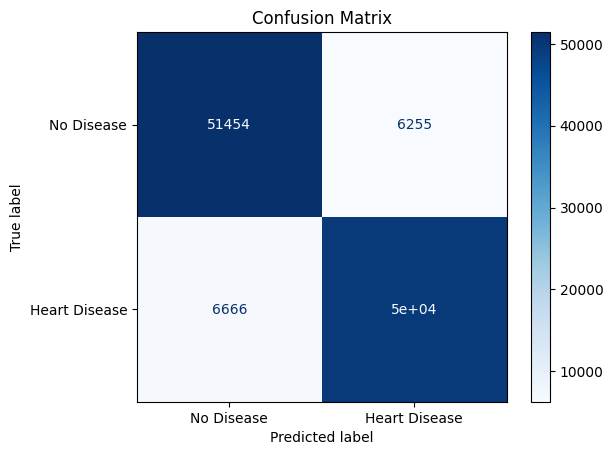


Top Features:
                    Feature  Importance
6                  Thallium    0.571561
8           Chest pain type    0.133475
9           Exercise angina    0.089636
0   Number of vessels fluro    0.064035
10              Slope of ST    0.057878
7                       Sex    0.045665
1             ST depression    0.017334
5                    Max HR    0.013721
2                       Age    0.004587
3               Cholesterol    0.001282


In [19]:
from xgboost import XGBClassifier

# -----------------------------
# 1️⃣ Select features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# -----------------------------
# 4️⃣ Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# -----------------------------
# 5️⃣ Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

# -----------------------------
# 6️⃣ Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 7️⃣ Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(10))

0:	learn: 0.5998748	test: 0.5995602	best: 0.5995602 (0)	total: 781ms	remaining: 4m 32s
100:	learn: 0.2743671	test: 0.2740053	best: 0.2740053 (100)	total: 57.7s	remaining: 2m 22s
200:	learn: 0.2722164	test: 0.2721735	best: 0.2721735 (200)	total: 1m 48s	remaining: 1m 20s
300:	learn: 0.2711197	test: 0.2714552	best: 0.2714552 (300)	total: 2m 33s	remaining: 25s
349:	learn: 0.2706977	test: 0.2712403	best: 0.2712403 (349)	total: 2m 58s	remaining: 0us

bestTest = 0.2712403413
bestIteration = 349

Train Accuracy: 0.8874
Test Accuracy:  0.8865

Classification Report - CatBoost:
               precision    recall  f1-score   support

   No Disease       0.88      0.89      0.89     56909
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    113400
    macro avg       0.89      0.89      0.89    113400
 weighted avg       0.89      0.89      0.89    113400



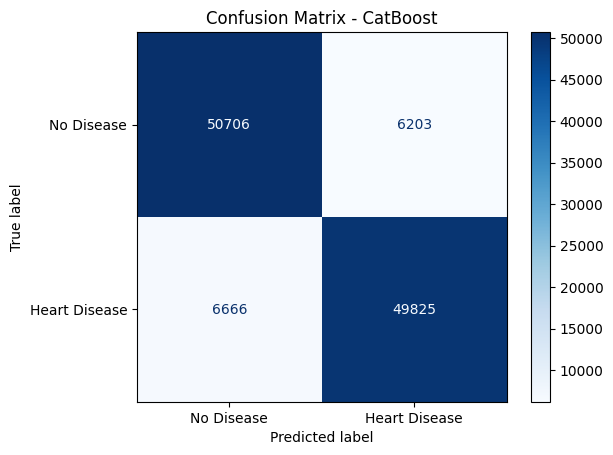


Top Features:
                    Feature  Importance
5                    Max HR   20.333572
6                  Thallium   20.141276
8           Chest pain type   17.032589
0   Number of vessels fluro   11.053320
9           Exercise angina    7.418380
1             ST depression    6.846809
10              Slope of ST    6.123143
7                       Sex    5.774058
2                       Age    3.469278
3               Cholesterol    1.276173


In [30]:
# -----------------------------
# 0️⃣ Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from catboost import CatBoostClassifier

# -----------------------------
# 1️⃣ Select features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR", "Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# Combine numerical + categorical features (no one-hot encoding)
X = df[numerical_features + categorical_features]
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Train CatBoost
cat_features_indices = [X.columns.get_loc(col) for col in categorical_features]

cat_model = CatBoostClassifier(
    iterations=350,
    learning_rate=0.1,
    depth=5,
    random_seed=42,
    eval_metric="Logloss",
    verbose=100
)

cat_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# -----------------------------
# 4️⃣ Predictions
y_pred_train = cat_model.predict(X_train)
y_pred_test = cat_model.predict(X_test)
y_prob_test = cat_model.predict_proba(X_test)[:,1]

# -----------------------------
# 5️⃣ Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# -----------------------------
# 6️⃣ Classification Report
print("\nClassification Report - CatBoost:")
print(classification_report(y_test, y_pred_test, target_names=["No Disease", "Heart Disease"]))

# -----------------------------
# 7️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - CatBoost")
plt.show()

# -----------------------------
# 8️⃣ Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [13:36:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.4, 'colsample_bytree': 0.9}
Test Accuracy: 0.8870

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.89      0.89     57909
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    114400
    macro avg       0.89      0.89      0.89    114400
 weighted avg       0.89      0.89      0.89    114400



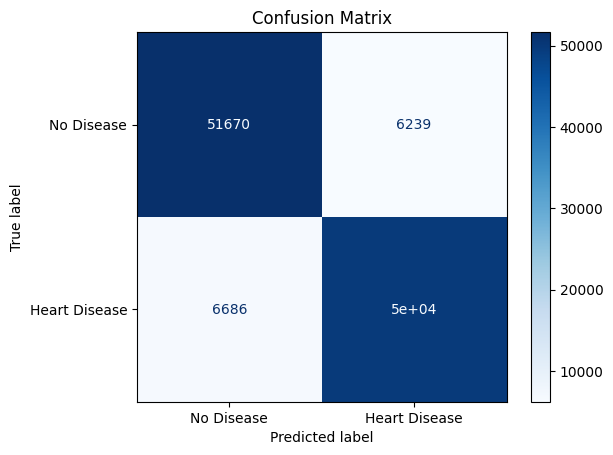


Top Features:
                    Feature  Importance
10                 Thallium    0.525024
7           Chest pain type    0.143027
8           Exercise angina    0.115255
0   Number of vessels fluro    0.065375
9               Slope of ST    0.061320
6                       Sex    0.046963
1             ST depression    0.019511
5                    Max HR    0.014767
2                       Age    0.005943
3               Cholesterol    0.001657


In [60]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST", "Thallium"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# -----------------------------
# 4️⃣ XGBoost hyperparameter tuning using RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Define the hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,           # number of random combinations
    scoring='accuracy',
    cv=5,                # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)
best_xgb = random_search.best_estimator_

# -----------------------------
# 5️⃣ Predictions & Evaluation
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 6️⃣ Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(10))

In [ ]:
# -----------------------------
# SVM Classifier with class_weight balanced + k-fold CV
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Define SVM classifier with class_weight balanced
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)

# 5️⃣ Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=kf, scoring="accuracy")

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# 6️⃣ Train on full training set
svm_model.fit(X_train_scaled, y_train)

# 7️⃣ Evaluate on test set
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

In [1]:
# -----------------------------
# SVM Classifier (single train/test split)
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay



In [11]:
# 1️⃣ Features and target
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR"]
X = df[numerical_features]
y = df["Heart Disease"]

# 2️⃣ Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Class distribution in training set:\n{y_train.value_counts()}")


Training samples: 504000
Testing samples: 126000
Class distribution in training set:
Heart Disease
0    278037
1    225963
Name: count, dtype: int64


In [ ]:
# 4️⃣ Define SVM classifier with class_weight balanced
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)

# 5️⃣ Train SVM on training set
svm_model.fit(X_train_scaled, y_train)

# 6️⃣ Predict on test set
y_pred = svm_model.predict(X_test_scaled)

# 7️⃣ Evaluate
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [17:39:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 230837
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 456800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494665 -> initscore=-0.021341
[LightGBM] [Info] Start training from score -0.021341

🔥 Ensemble Accuracy: 0.8869

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.89      0.89     57709
Heart Disease       0.89      0.88      0.89     56491

     accuracy                           0.89    114200
    macro avg       0.89      0.89      0.89    114200
 weighted avg       0.89      

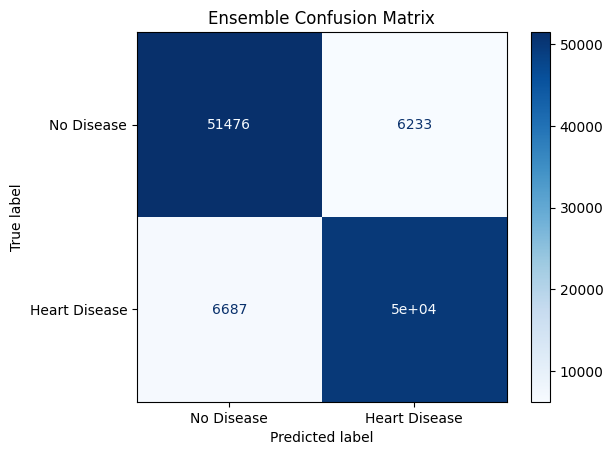

XGB weight 0.8 → Accuracy: 0.8870
XGB weight 0.9 → Accuracy: 0.8870
XGB weight 1.0 → Accuracy: 0.8872
XGB weight 2.0 → Accuracy: 0.8869


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =========================================
# 1️⃣ SAME FEATURE ENGINEERING (KEEP YOUR BEST VERSION)
# =========================================

numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]

# =========================================
# 2️⃣ SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 3️⃣ MODELS
# =========================================

# ✅ Your BEST XGBoost
xgb_model = XGBClassifier(
    subsample=0.9,
    reg_lambda=1.5,
    reg_alpha=0,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

# ✅ LightGBM (strong default tuned slightly)
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train both
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# =========================================
# 4️⃣ ENSEMBLE (SOFT VOTING)
# =========================================

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

# 🔥 Weighted average (IMPORTANT)
final_prob = (0.6 * xgb_prob) + (0.4 * lgb_prob)

# Convert to class
y_pred = (final_prob >= 0.5).astype(int)

# =========================================
# 5️⃣ EVALUATION
# =========================================

acc = accuracy_score(y_test, y_pred)
print(f"\n🔥 Ensemble Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Ensemble Confusion Matrix")
plt.show()

# =========================================
# 6️⃣ OPTIONAL: TRY DIFFERENT WEIGHTS
# =========================================

for w in [0.8, 0.9, 1,2]:
    blended = (w * xgb_prob) + ((1 - w) * lgb_prob)
    pred = (blended >= 0.5).astype(int)
    acc = accuracy_score(y_test, pred)
    print(f"XGB weight {w:.1f} → Accuracy: {acc:.4f}")